In [26]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust, fixest)

In [2]:
file_list <- list.files(path = "../data/output", pattern = "data-.*\\.csv", full.names = TRUE)

# Read all csvs 2009-2019 into one data frame
hwk.data <- file_list %>%
map_df(~read_csv(., col_types = cols(provider_number = col_character()))) %>%
  mutate(year = as.numeric(year)) %>%  
  filter(year >= 2009 & year <= 2019)

### Question 1: From 2009-2019, how many hospitals filed more than one report in the same year?

In [3]:
# Load raw data
final.hcris.v1996 <- read_tsv('../data/input/HCRIS_Data_v1996.txt')
final.hcris.v2010 <- read_tsv('../data/input/HCRIS_Data_v2010.txt')

# Remerge
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010)

# Create the missing column again
final.hcris <- final.hcris %>%
  mutate(fyear = year(mdy(fy_end))) %>% 
    # creates total report column
  add_count(provider_number, fyear, name="total_reports") 

# Analysis for q1
q1_data <- final.hcris %>%
  filter(fyear >= 2009 & fyear <= 2019) %>%
  group_by(fyear) %>%
  summarize(mult_report_hospitals = n_distinct(provider_number[total_reports > 1]))

Rows: 78508 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (34): report, status, year, beds, tot_charges, net_pat_rev, tot_discount...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 85496 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_re...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


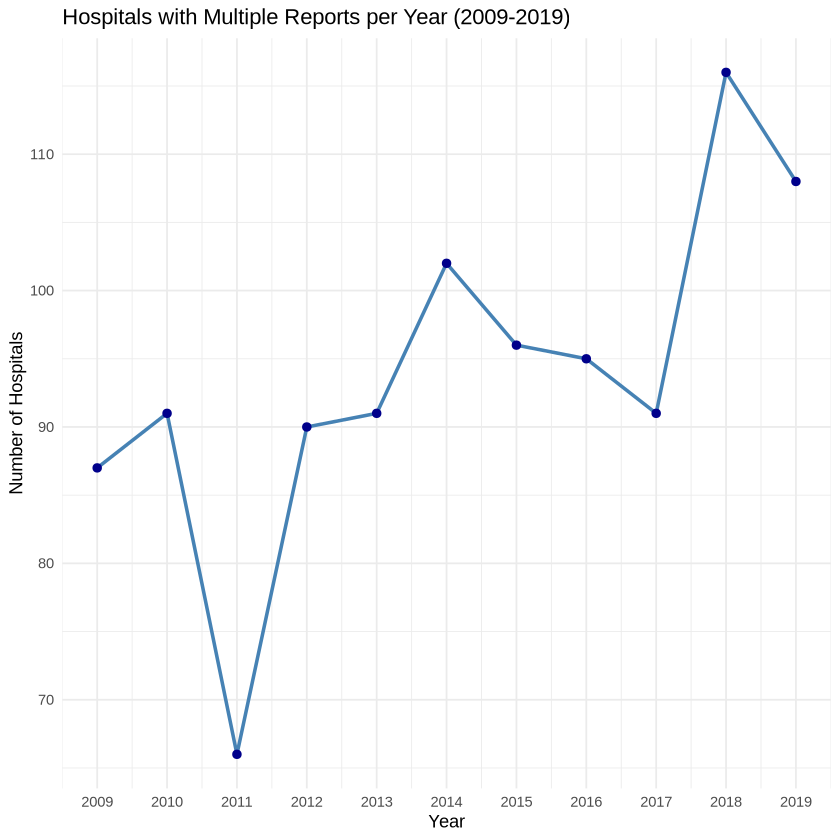

In [4]:
# Create line graph
ggplot(q1_data, aes(x = fyear, y = mult_report_hospitals)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 2) +
  scale_x_continuous(breaks = 2009:2019) +
  theme_minimal() +
  labs(
    title = "Hospitals with Multiple Reports per Year (2009-2019)",
    x = "Year",
    y = "Number of Hospitals",
  )

### Question 2: After removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [5]:
unique_hospitals <- n_distinct(hwk.data$provider_number)
cat("Total unique Medicare provider numbers in cleaned data:", unique_hospitals, "\n")

Total unique Medicare provider numbers in cleaned data: 6897 


### Question 3: From 2009-2019, what is the distribution of total charges (tot_charges in the data) in each year? 

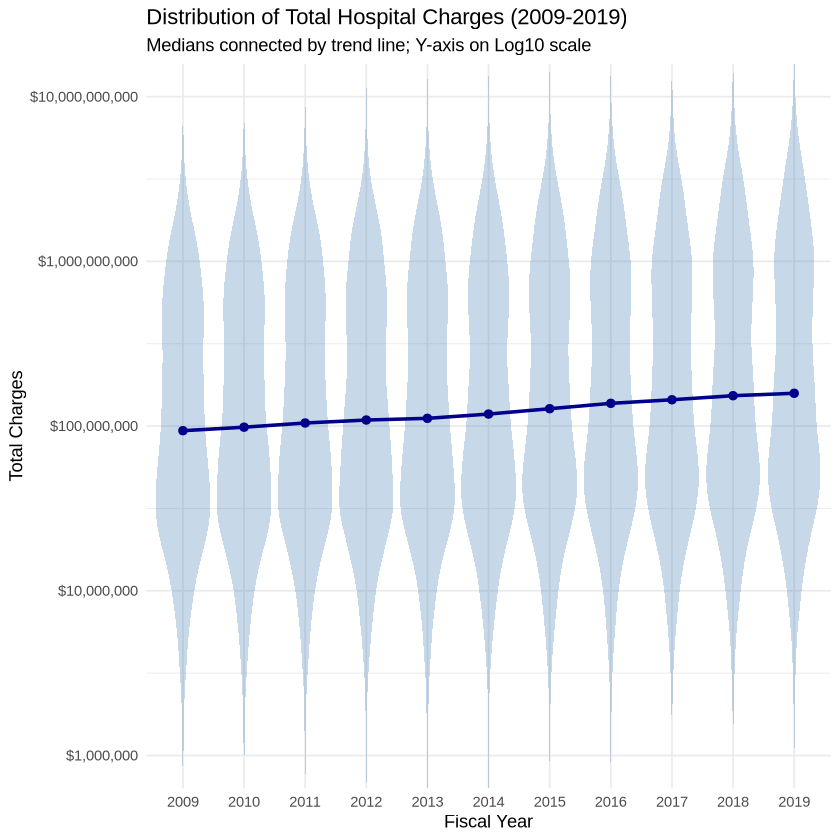

In [15]:
# Prep data
q3_plot_data <- hwk.data %>%
  filter(tot_charges > 0) %>%
  mutate(year_factor = as.factor(year))

# Create the plot
ggplot(q3_plot_data, aes(x = year_factor, y = tot_charges)) +
  # The Violin Shape
  geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
  # Median Points and Trend Line
  stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
  stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", linewidth = 1) +
  
  # Log scale for the y-axis labels
  scale_y_log10(labels = label_dollar()) + 
  
  # Zoom in to remove empty space
  coord_cartesian(ylim = c(10^6, 10^10)) + 
  
  # Make it pretty
  theme_minimal() +
  labs(
    title = "Distribution of Total Hospital Charges (2009-2019)",
    subtitle = "Medians connected by trend line; Y-axis on Log10 scale",
    x = "Fiscal Year",
    y = "Total Charges"
  )

### Question 4: From 2009-2019, what is the distribution of estimated prices in each year?

In [21]:
# Calculate price components in main data frame
hwk.data <- hwk.data %>%
  mutate(
    # Formula: discount_factor = 1 - tot_discounts / tot_charges
    discount_factor = 1 - (tot_discounts / tot_charges),
    
    # Make sure discount_factor is finite
    discount_factor = ifelse(is.finite(discount_factor), discount_factor, 1),
    
    # Formula: price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    
    # Formula: price_denom = tot_discharges - mcare_discharges
    price_denom = tot_discharges - mcare_discharges,
    
    # Final price calc
    price = price_num / price_denom
  )

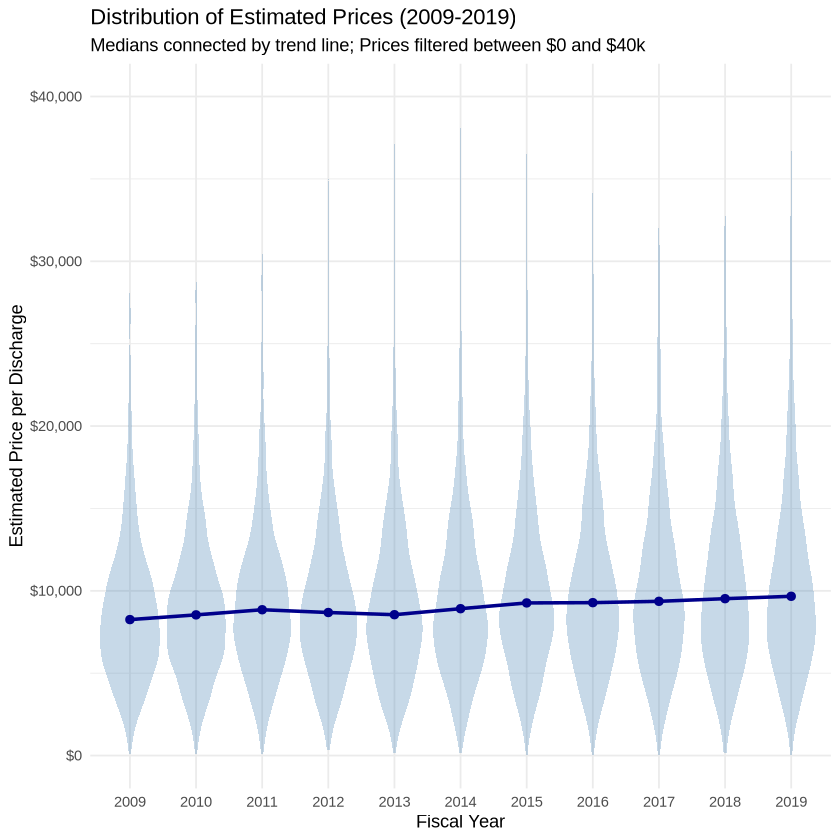

In [22]:
# Prep data for the violin plot (no negative values, outliers)
q4_plot_data <- hwk.data %>%
  filter(price > 0 & price < 40000) %>% 
  mutate(year_factor = as.factor(year))

# Create plot
ggplot(q4_plot_data, aes(x = year_factor, y = price)) +
  # Violin layer
  geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
  # Median points & trend line
  stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
  stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", size = 1) +
  
  # Linear scale
  scale_y_continuous(labels = scales::label_dollar()) +
  
  theme_minimal() +
  labs(
    title = "Distribution of Estimated Prices (2009-2019)",
    subtitle = "Medians connected by trend line; Prices filtered between $0 and $40k",
    x = "Fiscal Year",
    y = "Estimated Price per Discharge"
  )

### Question 5: What share of hospitals are penalized under the HRRP/VBP? (2012-2019)

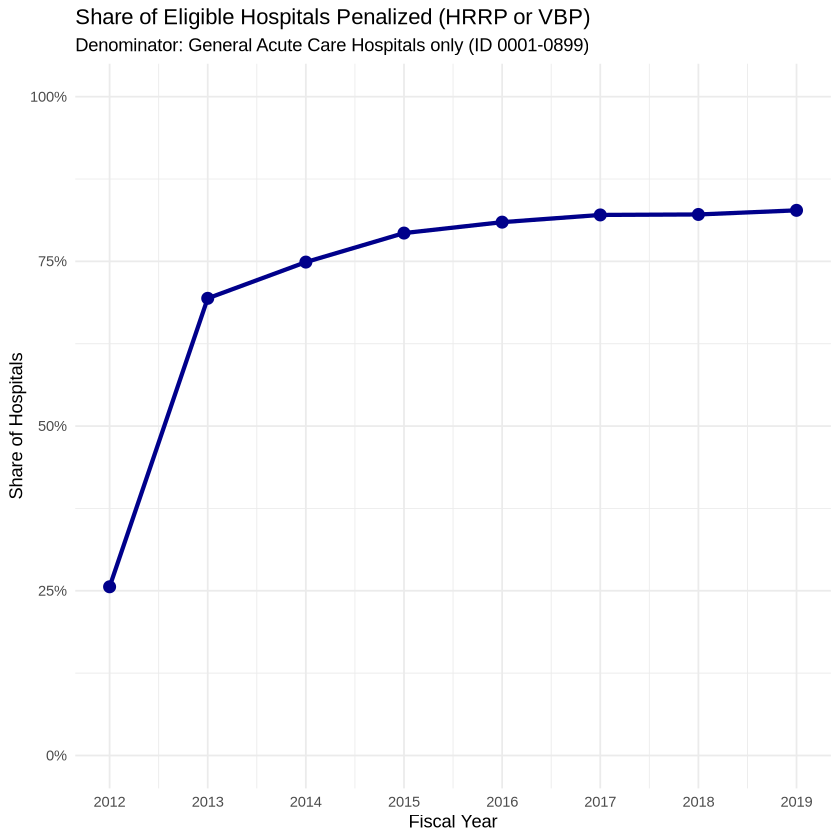

In [25]:
q5_plot_data <- hwk.data %>%
  filter(year >= 2012 & year <= 2019) %>%
  
  # Clean up IDs (The 0001-0899 filter)
  mutate(
    clean_id = sprintf("%06s", as.character(provider_number)),
    id_suffix = as.numeric(substr(clean_id, nchar(clean_id) - 3, nchar(clean_id)))
  ) %>%
  filter(id_suffix >= 1 & id_suffix <= 899) %>%
  
  # Implement penalty logic 
  # If HRRP is not zero, it's a penalty
  # If VBP is not zero, we need to check if penalty or bonus
  mutate(
    # Check for HRRP adjustment
    hrrp_pen = ifelse(!is.na(hrrp_payment) & hrrp_payment != 0, 1, 0),
    
    # Check for VBP penalty
    vbp_pen = ifelse(!is.na(hvbp_payment) & hvbp_payment < 0, 1, 0),
    is_penalized = ifelse(hrrp_pen == 1 | vbp_pen == 1, 1, 0)
  ) %>%
  
  # Summarize
  group_by(year) %>%
  summarize(
    share_penalized = mean(is_penalized, na.rm = TRUE),
    hosp_count = n()
  )
# Create graph
ggplot(q5_plot_data, aes(x = year, y = share_penalized)) +
  geom_line(color = "darkblue", size = 1.2) +
  geom_point(color = "darkblue", size = 3) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0, 1)) +
  scale_x_continuous(breaks = 2012:2019) +
  theme_minimal() +
  labs(
    title = "Share of Eligible Hospitals Penalized (HRRP or VBP)",
    subtitle = "Denominator: General Acute Care Hospitals only (ID 0001-0899)",
    x = "Fiscal Year",
    y = "Share of Hospitals"
  )

### Question 6: Provide a summary of OLS estimates of the effect of net penalties on price changes.

In [30]:
# Create cross-sectional data
iv_data <- hwk.data %>%
  # Range
  filter(year >= 2009 & year <= 2014) %>%
  # Keep only general acute care hospitals (0001-0899)
  mutate(clean_id = sprintf("%06s", as.character(provider_number)),
         id_suffix = as.numeric(substr(clean_id, 3, 6))) %>%
  filter(id_suffix <= 899) %>%
  group_by(provider_number) %>%
  summarize(
    # Outcome: Price change from 2011 to 2014
    price_change = mean(price[year == 2014], na.rm=TRUE) - mean(price[year == 2011], na.rm=TRUE),
    
    # Treatment: Net penalty in 2012 (Sum of HRRP and VBP)
    net_penalty = mean(coalesce(hrrp_payment[year == 2012], 0) + 
                       coalesce(hvbp_payment[year == 2012], 0), na.rm=TRUE),
    
    # Instrument: Avg Medicare discharges 2009-2011
    avg_mcare_disch = mean(mcare_discharges[year <= 2011], na.rm = TRUE),
    
    # Controls: Avg Bed size and Medicaid discharges 2009-2011
    avg_beds = mean(beds[year <= 2011], na.rm = TRUE),
    avg_mcaid_disch = mean(mcaid_discharges[year <= 2011], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  # Define penalty_amt as the positive dollar amount lost (reduction in payment)
  mutate(penalty_amt = abs(pmin(net_penalty, 0))) %>%
  # Remove hospitals missing the outcome or the instrument
  filter(!is.na(price_change), !is.na(avg_mcare_disch))

In [31]:
# Baseline
m1_ols <- feols(price_change ~ penalty_amt, data = iv_data)

# Baseline + beds
m2_ols <- feols(price_change ~ penalty_amt + avg_beds, data = iv_data)

# Baseline + beds + medicaid
m3_ols <- feols(price_change ~ penalty_amt + avg_beds + avg_mcaid_disch, data = iv_data)

# Display table
etable(m1_ols, m2_ols, m3_ols, 
       title = "Table 1: OLS Estimates of Net Penalties on Price Changes",
       headers = c("Baseline", "+ Beds", "+ Medicaid"),
       tex = FALSE)

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 17 observations removed because of NA values (RHS: 17).



,,m1_ols,m2_ols,m3_ols
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,193.8 (509.6),154.8 (516.4),306.5 (466.6)
5,penalty_amt,0.0105 (0.0416),0.0101 (0.0416),0.0058 (0.0302)
6,avg_beds,,0.1564 (0.3320),0.1101 (0.2411)
7,avg_mcaid_disch,,,0.1328 (0.1749)
8,_______________,_______________,_______________,_______________
9,S.E. type,IID,IID,IID


### Question 7: Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values (`geom_point()`).”


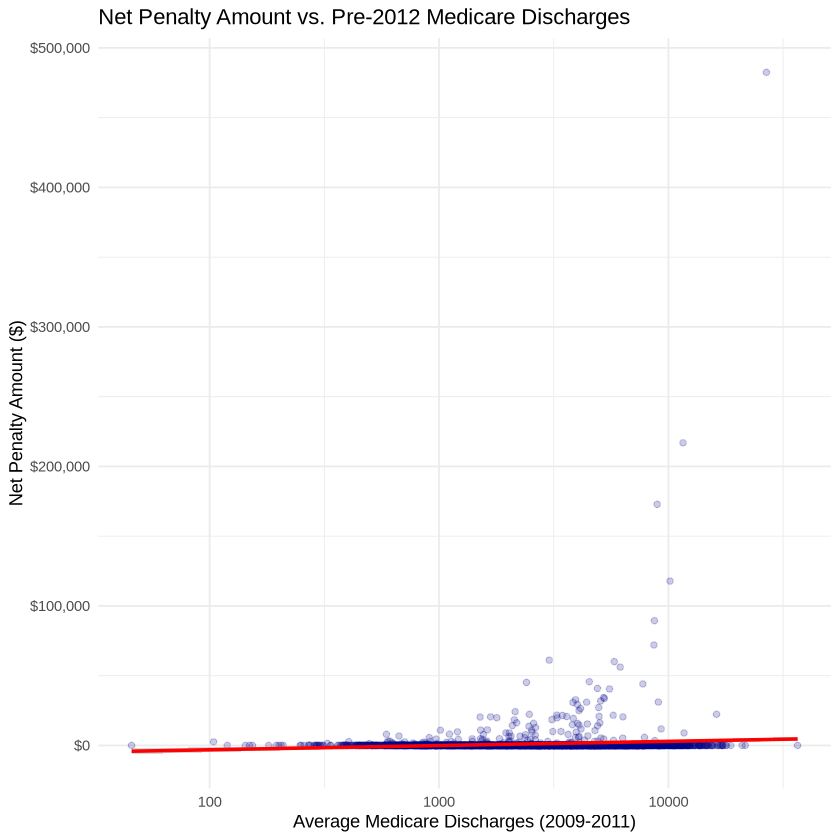

In [34]:
ggplot(iv_data, aes(x = avg_mcare_disch, y = penalty_amt)) +
  geom_point(alpha = 0.2, color = "darkblue") +
  geom_smooth(method = "lm", color = "red") +
  scale_x_log10() +
  scale_y_continuous(labels = scales::dollar_format()) +
  theme_minimal() +
  labs(
    title = "Net Penalty Amount vs. Pre-2012 Medicare Discharges",
    x = "Average Medicare Discharges (2009-2011)",
    y = "Net Penalty Amount ($)"
  )

### Question 8: Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. 

In [35]:
# First stage models
# Treatment (penalty) ~ instrument (medicare discharges) + controls
fs_1 <- feols(penalty_amt ~ avg_mcare_disch, data = iv_data)
fs_2 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds, data = iv_data)
fs_3 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Reduced form models
# Outcome (price change) ~ instrument (medicare discharges) + controls
rf_1 <- feols(price_change ~ avg_mcare_disch, data = iv_data)
rf_2 <- feols(price_change ~ avg_mcare_disch + avg_beds, data = iv_data)
rf_3 <- feols(price_change ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Summary tables
# First stage
etable(fs_1, fs_2, fs_3, 
       title = "Table 2: First Stage Results (Dep. Var: Net Penalty)",
       headers = c("Baseline", "+ Beds", "+ Medicaid"))

# Reduced form
etable(rf_1, rf_2, rf_3, 
       title = "Table 3: Reduced Form Results (Dep. Var: Price Change)",
       headers = c("Baseline", "+ Beds", "+ Medicaid"))

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 17 observations removed because of NA values (LHS: 5, RHS: 12).

NOTE: 12 observations removed because of NA values (RHS: 12).



,,fs_1,fs_2,fs_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,penalty_amt,penalty_amt,penalty_amt
3,,,,
4,Constant,"-1,253.9*** (366.3)","-1,255.2*** (366.5)","-1,240.6*** (372.8)"
5,avg_mcare_disch,0.6567*** (0.0766),0.6557*** (0.0771),0.6720*** (0.0887)
6,avg_beds,,0.0197 (0.1576),0.0213 (0.1581)
7,avg_mcaid_disch,,,-0.0462 (0.1307)
8,_______________,___________________,___________________,___________________
9,S.E. type,IID,IID,IID


,,rf_1,rf_2,rf_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,"-1,123.2 (773.5)","-1,128.4 (773.9)",-326.7 (568.7)
5,avg_mcare_disch,0.3678* (0.1618),0.3637* (0.1627),0.2629. (0.1354)
6,avg_beds,,0.0798 (0.3332),0.0743 (0.2414)
7,avg_mcaid_disch,,,-0.0540 (0.1995)
8,_______________,________________,________________,________________
9,S.E. type,IID,IID,IID


### Question 9: Provide a summary of IV estimates of the effect of net penalties on price changes. 

In [36]:
# IV specifications
m1_iv <- feols(price_change ~ 1 | penalty_amt ~ avg_mcare_disch, data = iv_data)
m2_iv <- feols(price_change ~ avg_beds | penalty_amt ~ avg_mcare_disch, data = iv_data)
m3_iv <- feols(price_change ~ avg_beds + avg_mcaid_disch | penalty_amt ~ avg_mcare_disch, data = iv_data)

# Show IV results
etable(m1_iv, m2_iv, m3_iv, 
       title = "Table 4: IV Estimates of Net Penalties on Price Changes",
       headers = c("Baseline", "+ Beds", "+ Medicaid"))

NOTE: 5 observations removed because of NA values (IV: 5/0).

NOTE: 5 observations removed because of NA values (IV: 5/0).

NOTE: 17 observations removed because of NA values (RHS: 12, IV: 5/0).



,,m1_iv,m2_iv,m3_iv
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,-420.9 (597.8),-432.2 (599.8),159.5 (487.8)
5,penalty_amt,0.5588* (0.2554),0.5534* (0.2572),0.3895. (0.2084)
6,avg_beds,,0.0688 (0.3455),0.0660 (0.2499)
7,avg_mcaid_disch,,,-0.0353 (0.2017)
8,_______________,________________,________________,________________
9,S.E. type,IID,IID,IID


### Question 10: Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The IV estimate represents a Local ATE because it identifies the causal impact of net penalties on price changes specifically for the hospitals whose penalty status was directly influenced by their volume of Medicare discharges (the instrument).
The local effect ($0.3895$) is significantly larger and more statistically meaningful than the overall ATE estimated by OLS ($0.0058$).